In [83]:
import pandas as pd 


In [84]:
fear_greed = pd.read_csv('fear_greed_index.csv')
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [85]:
historical_data = pd.read_csv('historical_data.csv')
historical_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [86]:
fear_greed.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [87]:
historical_data.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [88]:
fear_greed.duplicated().sum()

np.int64(0)

In [89]:
historical_data.duplicated().sum()

np.int64(0)

In [90]:
fear_greed['timestamp'] = pd.to_datetime(fear_greed['date'])
historical_data['timestamp'] = pd.to_datetime(historical_data['Timestamp IST'], format="%d-%m-%Y %H:%M")

# Merge on date (day-level match)
merged = pd.merge(
    historical_data,
    fear_greed,
    left_on=historical_data['timestamp'].dt.date,
    right_on=fear_greed['timestamp'].dt.date,
    how="left"
)
merged

,key_0,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,...,Order ID,Crossed,Fee,Trade ID,Timestamp,timestamp_x,timestamp_y,value,classification,date
0,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed,2024-12-02
1,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed,2024-12-02
2,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed,2024-12-02
3,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed,2024-12-02
4,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed,2024-12-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,2025-04-25,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25,60.0,Greed,2025-04-25
211220,2025-04-25,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25,60.0,Greed,2025-04-25
211221,2025-04-25,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25,60.0,Greed,2025-04-25
211222,2025-04-25,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25,60.0,Greed,2025-04-25


In [91]:
merged.isnull().sum()

key_0               0
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
timestamp_x         0
timestamp_y         6
value               6
classification      6
date                6
dtype: int64

In [92]:
merged = merged.drop(columns=["timestamp_x", "timestamp_y"])

In [93]:
mode_value = merged["classification"].mode()[0]
merged["classification"] = merged["classification"].fillna(mode_value)

In [94]:
merged.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,value
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05,211218.000000
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12,51.649656
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09,21.012784
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,10.000000
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12,33.000000
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12,49.000000
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12,72.000000
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,94.000000


In [95]:
merged.shape

(211224, 20)

In [96]:
#TO check Profitability
trader_pnl = merged.groupby("Account")['Closed PnL'].sum()
trader_pnl.sum()

np.float64(10296958.943436)

In [97]:
#Average PnL per trade
avg_pnl = merged.groupby("Account")['Closed PnL'].mean()
avg_pnl
     

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    419.127768
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd      6.577654
0x271b280974205ca63b716753467d5a371de622ab    -18.492043
0x28736f43f1e871e6aa8b1148d38d4994275d72c4      9.951530
0x2c229d22b100a7beb69122eed721cee9b24011dd     52.071011
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    -38.286626
0x39cef799f8b69da1995852eea189df24eb5cae3c      4.028119
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    161.133275
0x420ab45e0bd8863569a5efbb9c05d91f40624641    520.902331
0x430f09841d65beb3f27765503d0f850b8bce7713    336.735548
0x47add9a56df66b524d5e2c1993a43cde53b6ed85     12.130968
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    155.589314
0x4f93fead39b70a1824f981a54d4e55b278e9f760     40.740489
0x513b8629fe877bb581bf244e326a047b249c4ff1     68.684419
0x6d6a4b953f202f8df5bed40692e7fd865318264a    111.519197
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    270.034947
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    281.826227
0x75f7eeb85dc639d5e99c7

In [98]:
#comparing Profitability during Fear VS Greed period

sentiment_pnl = merged.groupby("classification")['Closed PnL'].mean()
sentiment_pnl

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.971904
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

In [99]:
import matplotlib.pyplot as plt

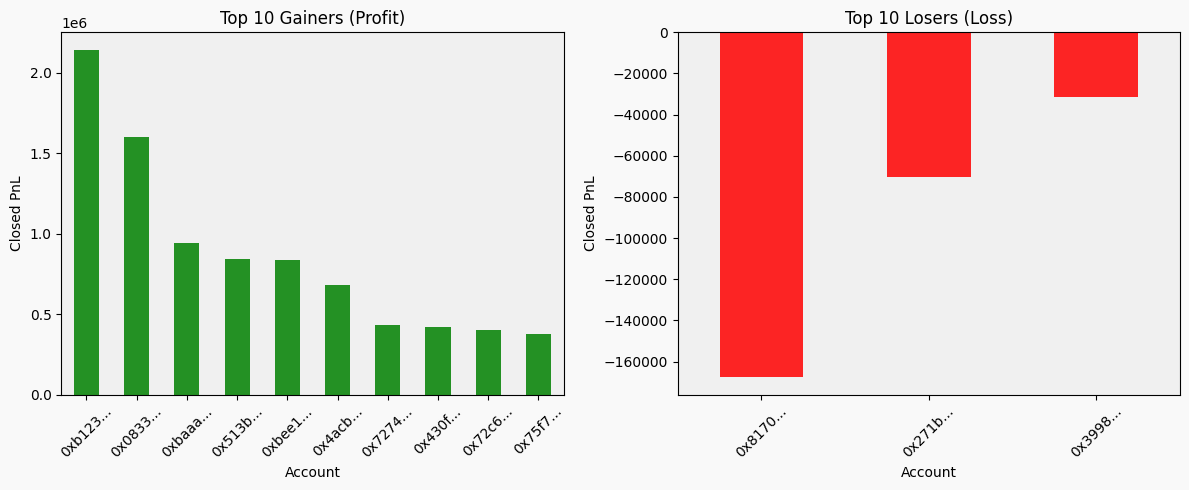

In [100]:
# Group by ORIGINAL account and calculate total Closed PnL
Account_pnl = merged.groupby("Account")["Closed PnL"].sum()

# Top 10 gainers
top10_gainers = (Account_pnl[Account_pnl > 0].sort_values(ascending=False).head(10))
# Top 10 losers
top10_losers = (Account_pnl[Account_pnl < 0].sort_values(ascending=True).head(10))

# Shorten account names ONLY for displaying
top10_gainers.index = top10_gainers.index.str.slice(0, 6) + "..."
top10_losers.index = top10_losers.index.str.slice(0, 6) + "..."

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Background
fig.patch.set_facecolor("#f9f9f9")
axes[0].set_facecolor("#f0f0f0")
axes[1].set_facecolor("#f0f0f0")

# -------------------------
# Top 10 Gainers
# -------------------------
top10_gainers.plot(kind="bar",ax=axes[0],color="green",alpha=0.85)

axes[0].set_title("Top 10 Gainers (Profit)",color="black")

axes[0].set_ylabel( "Closed PnL",color="black")

axes[0].set_xlabel( "Account",color="black")

axes[0].tick_params(axis="x", rotation=45, colors="black")

axes[0].tick_params(axis="y",colors="black")

# -------------------------
# Top 10 Losers
# -------------------------
top10_losers.plot(kind="bar",ax=axes[1], color="red",alpha=0.85)

axes[1].set_title( "Top 10 Losers (Loss)",color="black")

axes[1].set_ylabel("Closed PnL",  color="black")

axes[1].set_xlabel("Account",color="black")

axes[1].tick_params(axis="x",rotation=45,colors="black")

axes[1].tick_params(axis="y",colors="black")

# Make axis borders black
for ax in axes:
    for spine in ax.spines.values():
        spine.set_color("black")

plt.tight_layout()
plt.show()



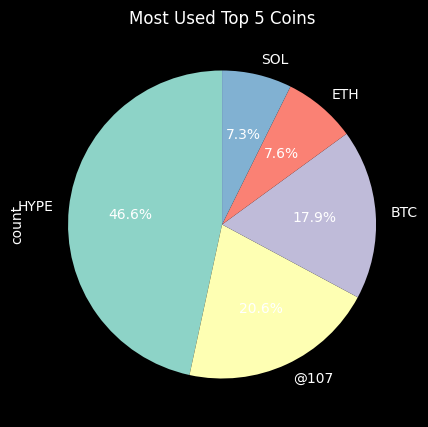

In [109]:
coin_counts = merged["Coin"].value_counts()

top5 = coin_counts.head(5)

# Sum of all the rest

# Plot
top5.plot(kind="pie", autopct="%1.1f%%", startangle=90,figsize=(5,5))
plt.title("Most Used Top 5 Coins")
plt.savefig('fig2')
plt.show()

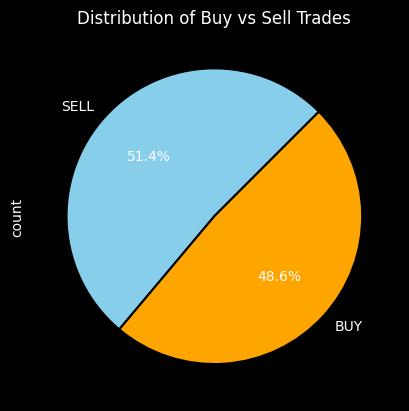

In [102]:
# Count how many trades were Buy vs Sell
side_counts = merged['Side'].value_counts()

side_counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'orange'] , wedgeprops={'edgecolor': 'black', 'linewidth': 1.5},startangle=45  )
plt.title("Distribution of Buy vs Sell Trades")
plt.show()
     

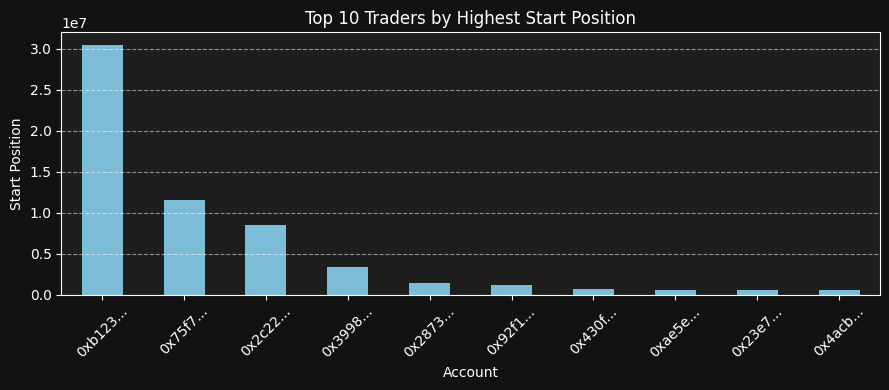

In [103]:
#Making the account name short
merged["Account"] = merged["Account"].str.slice(0, 6) + "..."

# Find maximum start position per trader
max_start_per_trader = merged.groupby('Account')['Start Position'].max()

# Get top 10 traders
top10_traders = max_start_per_trader.sort_values(ascending=False).head(10)

# Create figure and axes
fig, ax = plt.subplots(figsize=(9,4))

# Set dark background color inside plot
ax.set_facecolor('#1e1e1e')
fig.patch.set_facecolor('#121212')
# Plot bar chart with light color bars
top10_traders.plot(kind='bar', color='skyblue', alpha=0.9, ax=ax)

# Formatting
ax.set_title("Top 10 Traders by Highest Start Position", color="white")
ax.set_ylabel("Start Position", color="white")
ax.tick_params(axis='x', colors="white", rotation=45)
ax.tick_params(axis='y', colors="white")
ax.grid(axis='y', linestyle='--', alpha=0.5, color='white')

plt.tight_layout()
plt.savefig('fig4')
plt.show()

     

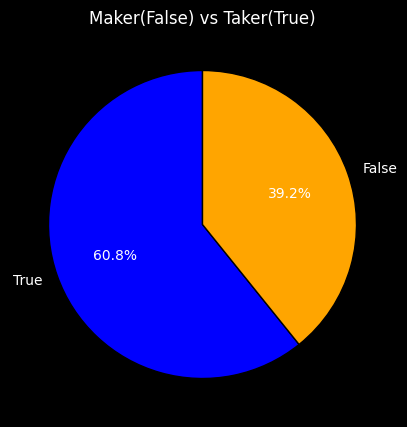

In [104]:
#Trade type counts
trade_type_counts = merged['Crossed'].value_counts()

plt.figure(figsize=(6,5))
plt.pie(
    trade_type_counts,
    labels=trade_type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors = ['blue','orange'],
    wedgeprops={"edgecolor": "black"}
)
plt.title("Maker(False) vs Taker(True)")
plt.savefig('fig5')
plt.show()
     

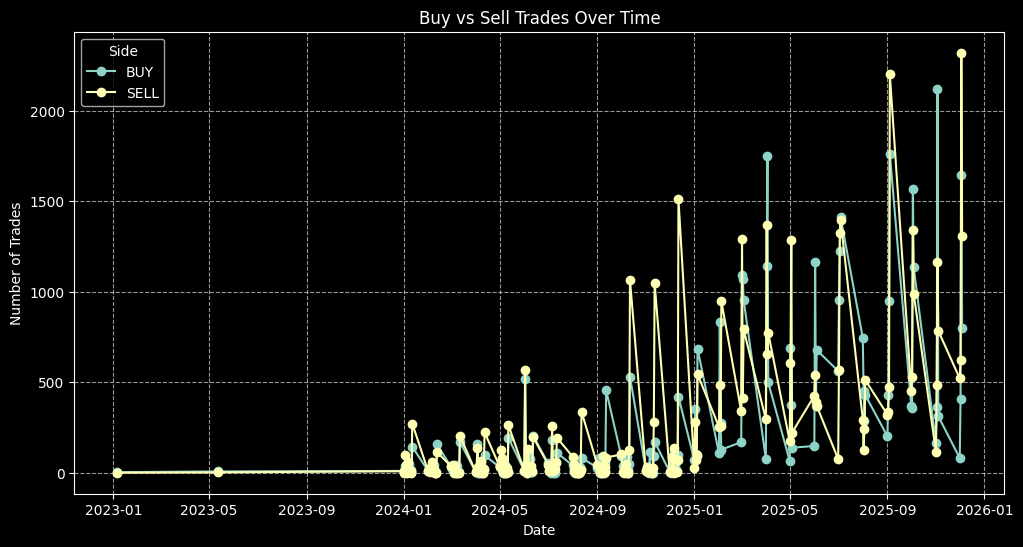

In [105]:
# Convert to datetime
merged['Timestamp IST'] = pd.to_datetime(merged['Timestamp IST'], errors='coerce')


# Convert timestamp to date if not already
merged['date'] = merged['Timestamp IST'].dt.date

# Count trades by date and side
direction_over_time = merged.groupby(['date', 'Side']).size().unstack(fill_value=0)

# Plot
direction_over_time.plot(kind='line', figsize=(12,6), marker='o')
plt.title("Buy vs Sell Trades Over Time")
plt.ylabel("Number of Trades")
plt.xlabel("Date")
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig('fig7')
plt.show()


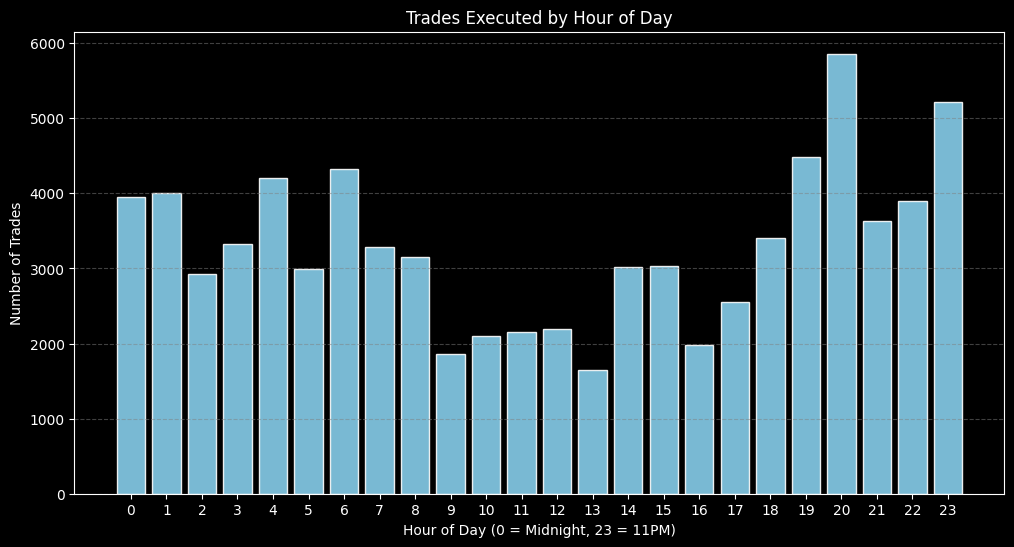

In [106]:
# Extract hour from timestamp
merged['hour'] = merged['Timestamp IST'].dt.hour

# Count trades per hour
trades_by_hour = merged['hour'].value_counts().sort_index()

# Dark background
plt.style.use("dark_background")

plt.figure(figsize=(12,6))

# Bar chart with light-colored bars
plt.bar(trades_by_hour.index, trades_by_hour.values,
        color='skyblue', edgecolor='white', alpha=0.9)

# Titles and labels with light colors
plt.title("Trades Executed by Hour of Day", color="white")
plt.xlabel("Hour of Day (0 = Midnight, 23 = 11PM)", color="white")
plt.ylabel("Number of Trades", color="white")

# X ticks for all 24 hours
plt.xticks(range(0,24), color="white")
plt.yticks(color="white")

# Grid in light color
plt.grid(axis='y', linestyle='--', alpha=0.5, color='gray')

plt.savefig('fig8')
plt.show()


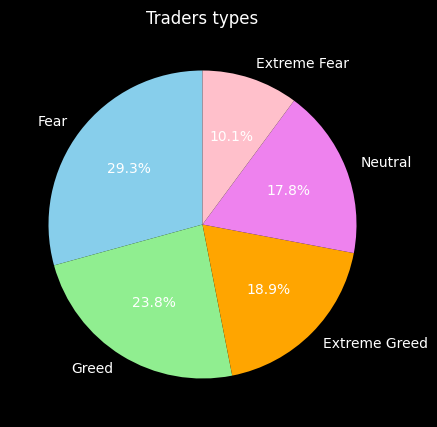

In [107]:
Types_of_Traders = merged['classification'].value_counts()
plt.figure(figsize=(6,5))
plt.pie(
    Types_of_Traders,
    labels=Types_of_Traders.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['skyblue','lightgreen','orange','violet','pink'],
    textprops={'color':'white'}
)
plt.title("Traders types")
plt.savefig('fig9')
plt.show()

In [110]:
merged.to_csv("merged_data.csv", index=False)